In [14]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

from pangya_physics.club import CLUBS
from pangya_physics.wind import Wind
from pangya_physics.ball import Ball
from pangya_physics.vector import Vector3D
from pangya_physics.simulator import PangyaSimulator, STEP_TIME
from pangya_physics.solver import find_power, create_initial_velocity

In [16]:
wind = Wind(0, 0)

In [17]:
selected_clubs = ["1W", "3W", "5I", "9I", "PW", "SW"]
target_distance = 200

In [18]:
def create_ball(club_info, power_percent):
    velocity = create_initial_velocity(
        club=club_info,
        power_percent=power_percent,
    )

    return Ball(
        position=Vector3D(0.0, 0.0, 0.0),
        velocity=velocity,
        rotation_spin=0.0,
        rotation_curve=0.0,
    )

In [19]:
def simulate_trajectory(club_name, target_distance, max_steps=1000):
    club_info = CLUBS[club_name]

    power_result = find_power(
        club=club_info,
        wind=wind,
        target_distance=target_distance,
        target_height=0.0,
    )

    ball = create_ball(
        club_info=club_info,
        power_percent=power_result.power_percent,
    )

    simulator = PangyaSimulator(
        ball=ball,
        club=club_info,
        wind=wind,
    )

    trajectory = []

    for step in range(max_steps):
        ball = simulator.step(STEP_TIME)

        trajectory.append({
            "club": club_name,
            "step": step,
            "time": step * STEP_TIME,
            "x": ball.position.x,
            "y": ball.position.y,
            "z": ball.position.z,
            "power_percent": power_result.power_percent,
            "target_distance": target_distance,
            "final_distance": power_result.final_distance,
        })

        if ball.position.y <= 0 and step > 0:
            break

    return trajectory

In [20]:
all_trajectories = []

for club in selected_clubs:
    all_trajectories.extend(
        simulate_trajectory(
            club_name=club,
            target_distance=target_distance,
        )
    )

df_traj = pd.DataFrame(all_trajectories)

df_traj.head()

,club,step,time,x,y,z,power_percent,target_distance,final_distance
0,1W,0,0.00,0.0,0.543219,3.158549,0.683347,200,200.692427
1,1W,1,0.02,0.0,1.069688,6.299465,0.683347,200,200.692427
2,1W,2,0.04,0.0,1.579518,9.422956,0.683347,200,200.692427
3,1W,3,0.06,0.0,2.072819,12.529229,0.683347,200,200.692427
4,1W,4,0.08,0.0,2.549699,15.618484,0.683347,200,200.692427


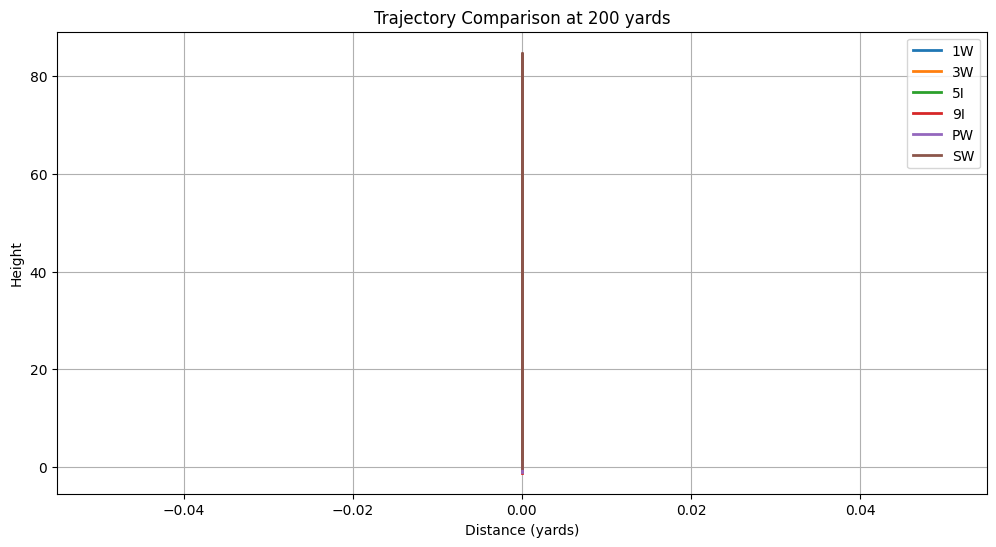

In [21]:
plt.figure(figsize=(12, 6))

for club in selected_clubs:
    club_df = df_traj[df_traj["club"] == club]

    plt.plot(
        club_df["x"],
        club_df["y"],
        label=club,
        linewidth=2,
    )

plt.title(f"Trajectory Comparison at {target_distance} yards")
plt.xlabel("Distance (yards)")
plt.ylabel("Height")
plt.grid(True)
plt.legend()

plt.show()

In [22]:
trajectory_summary = (
    df_traj.groupby("club")
    .agg(
        max_height=("y", "max"),
        final_distance=("x", "max"),
        flight_time=("time", "max"),
        lateral_deviation=("z", "last"),
        power_percent=("power_percent", "first"),
    )
    .reset_index()
)

trajectory_summary["power_percent"] = trajectory_summary["power_percent"] * 100

trajectory_summary

,club,max_height,final_distance,flight_time,lateral_deviation,power_percent
0,1W,9.699046,0.0,1.50,200.692427,68.334658
1,3W,15.883557,0.0,1.90,199.122081,73.701721
2,5I,34.942649,0.0,2.84,200.229001,76.562500
3,9I,62.845177,0.0,3.82,200.452640,88.339844
4,PW,72.468771,0.0,4.10,199.576698,92.500000
5,SW,84.733918,0.0,4.42,199.616386,110.312500


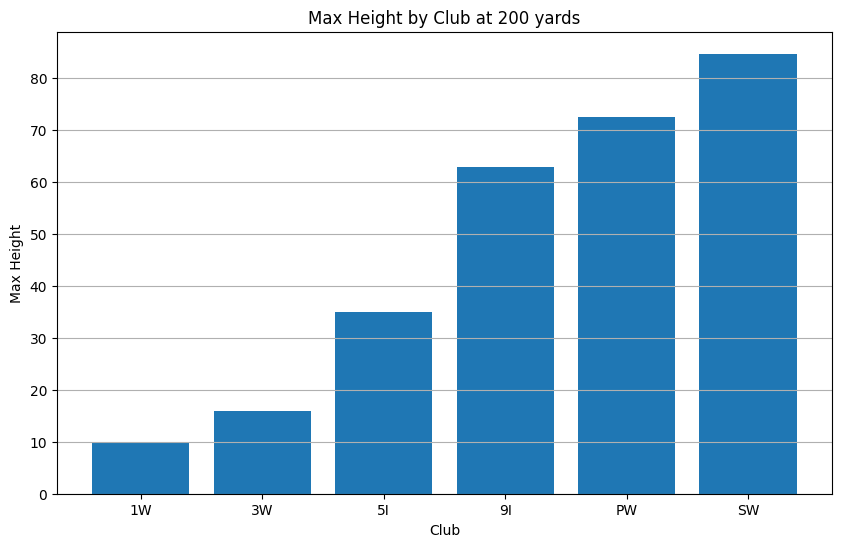

In [23]:
plt.figure(figsize=(10, 6))

plt.bar(
    trajectory_summary["club"],
    trajectory_summary["max_height"],
)

plt.title(f"Max Height by Club at {target_distance} yards")
plt.xlabel("Club")
plt.ylabel("Max Height")
plt.grid(axis="y")

plt.show()

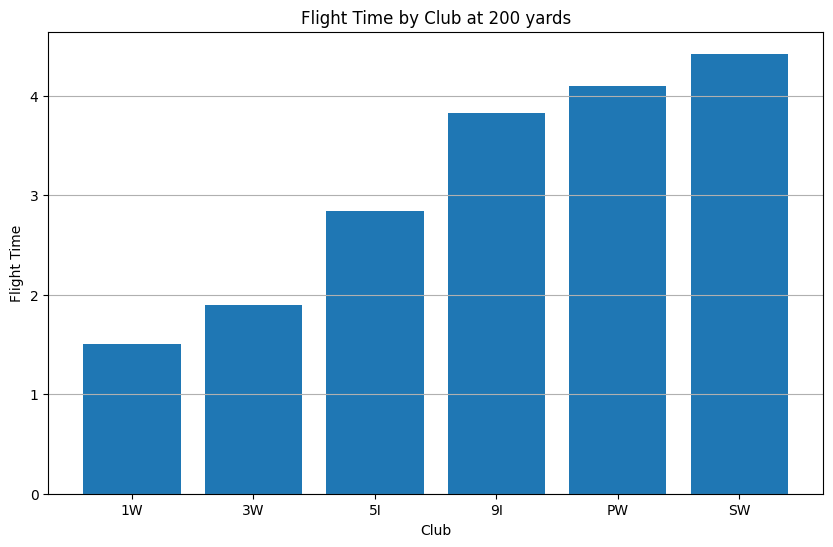

In [24]:
plt.figure(figsize=(10, 6))

plt.bar(
    trajectory_summary["club"],
    trajectory_summary["flight_time"],
)

plt.title(f"Flight Time by Club at {target_distance} yards")
plt.xlabel("Club")
plt.ylabel("Flight Time")
plt.grid(axis="y")

plt.show()

In [25]:
images_dir = PROJECT_ROOT / "docs" / "images"
images_dir.mkdir(parents=True, exist_ok=True)

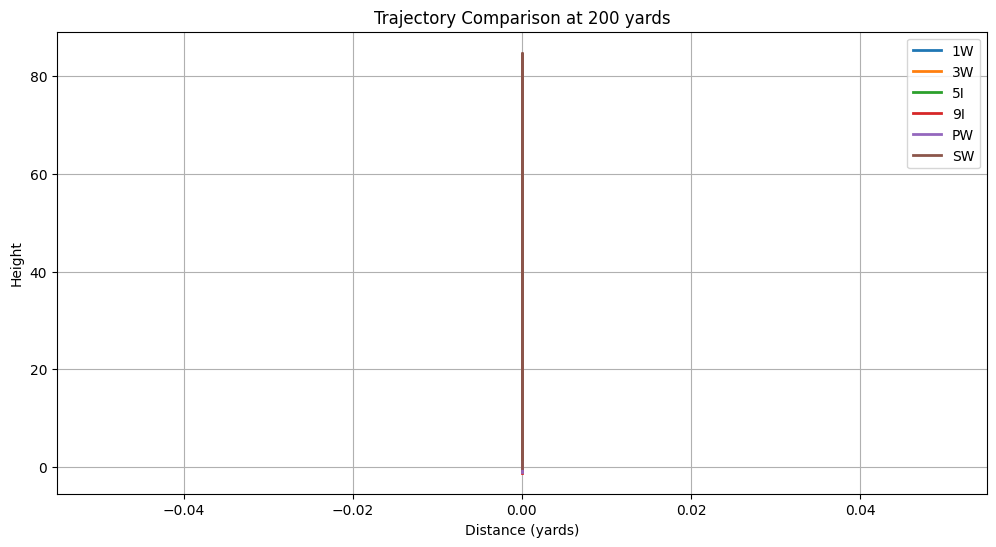

In [26]:
plt.figure(figsize=(12, 6))

for club in selected_clubs:
    club_df = df_traj[df_traj["club"] == club]

    plt.plot(
        club_df["x"],
        club_df["y"],
        label=club,
        linewidth=2,
    )

plt.title(f"Trajectory Comparison at {target_distance} yards")
plt.xlabel("Distance (yards)")
plt.ylabel("Height")
plt.grid(True)
plt.legend()

plt.savefig(
    images_dir / "trajectory_comparison_200y.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [27]:
output_path = PROJECT_ROOT / "data" / "processed" / "trajectory_visualizations.csv"

df_traj.to_csv(output_path, index=False)

output_path

WindowsPath('c:/Users/felip/OneDrive/Documentos/Nova pasta/pangya-shot-physics/data/processed/trajectory_visualizations.csv')